In [47]:
import random
import matplotlib.pyplot as plt
import numpy as np
import time
import seaborn as sns
import heapq

# parameters
growth_rate = 1
lightning_rate = 0.01

In [ ]:
def run_direct_simulation(L, T, growth_rate, lightning_rate):
    t = 0
    lattice = np.zeros(L, dtype=int)

    times = [0]

    # track density of forested sites over time
    density = [0.0]

    # track distribution of fire sizes
    fire_sizes = []

    # track the frequency of fires that are able to travel across the entire ring (which we call catastrophes)
    catastrophes = []
    fire_times = []
    start = time.time()
    while t < T:
        smallest_tau = np.inf
        event = None
        event_site = None

        # evaluate all rates for all possible events
        for site in range(L):
            if lattice[site] == 0:
                tau = np.random.exponential(1 / growth_rate)
                if tau < smallest_tau:
                    smallest_tau = tau
                    event = 'growth'
                    event_site = site

            tau = np.random.exponential(1 / lightning_rate)
            if tau < smallest_tau:
                smallest_tau = tau
                event = 'lightning'
                event_site = site

        # apply events
        if event == 'growth':
            lattice[event_site] = 1

        if event == 'lightning' and lattice[event_site] == 1:
            fire_size = 1
            fire_intensity = 1
            lattice[event_site] = 0
            current_site = event_site
            steps_toward_castastrophe = 0
            # As long as fire intensity is greater than zero
            while fire_intensity > 0:
                current_site = (current_site + 1) % L  # spread to next site
                steps_toward_castastrophe += 1
                if lattice[current_site] == 1:  # forested
                    fire_size += 1
                    fire_intensity += 1 # gains intensity
                    lattice[current_site] = 0  # burns
                else:
                    fire_intensity -= 1

            fire_sizes.append(fire_size)
            fire_times.append(t)
            if steps_toward_castastrophe >= L:
                catastrophes.append(1)
            else:
                catastrophes.append(0)

        times.append(t)
            
        density.append(np.mean(lattice))
        t += smallest_tau

    end = time.time()
    return times, density, fire_sizes, fire_times, catastrophes, end - start

def run_next_reaction_simulation(L, T, growth_rate, lightning_rate):
    t = 0
    lattice = np.zeros(L, dtype=int)

    times = [0]
    density = [0.0]
    fire_sizes = []
    catastrophes = []
    fire_times = []

    start = time.time()

    while t < T:
        # compute total rates instead of looping over all sites
        # growth can only happen at empty sites
        n_empty = L - np.sum(lattice)
        R_growth = growth_rate * n_empty
        R_lightning = lightning_rate * L
        R = R_growth + R_lightning

        # draw one exponential from total rate instead of 2L draws
        tau = np.random.exponential(1 / R)

        # use uniform to decide which event fires
        if np.random.uniform(0, 1) < R_growth / R:
            event = 'growth'
            # pick a random empty site instead of finding minimum tau
            empty_sites = np.where(lattice == 0)[0]
            event_site = np.random.choice(empty_sites)
        else:
            event = 'lightning'
            # pick a random site for lightning
            event_site = np.random.randint(0, L)

        if event == 'growth':
            lattice[event_site] = 1

        if event == 'lightning' and lattice[event_site] == 1:
            fire_size = 1
            fire_intensity = 1
            lattice[event_site] = 0
            current_site = event_site
            steps_toward_catastrophe = 0
            while fire_intensity > 0:
                current_site = (current_site + 1) % L
                steps_toward_catastrophe += 1
                if lattice[current_site] == 1:
                    fire_size += 1
                    fire_intensity += 1
                    lattice[current_site] = 0
                else:
                    fire_intensity -= 1

            fire_sizes.append(fire_size)
            fire_times.append(t)
            if steps_toward_catastrophe >= L:
                catastrophes.append(1)
            else:
                catastrophes.append(0)

        times.append(t)
        density.append(np.mean(lattice))
        t += tau

    end = time.time()
    return times, density, fire_sizes, fire_times, catastrophes, end - start

def schedule_events(event_queue, site, lattice, t):
    if lattice[site] == 0:
        tau_g = np.random.exponential(1 / growth_rate)
        heapq.heappush(event_queue, (t + tau_g, site, 'growth'))
    tau_l = np.random.exponential(1 / lightning_rate)
    heapq.heappush(event_queue, (t + tau_l, site, 'lightning'))
    return event_queue

def run_event_driven_simulation(L, T, growth_rate, lightning_rate):
    lattice = np.zeros(L, dtype=int)
    event_queue = []
    t = 0

    # tracking
    times = [0]
    density = [0.0]
    fire_sizes = []
    fire_times = []
    catastrophes = []

    for site in range(L):
        event_queue = schedule_events(event_queue, site, lattice, t)

    start = time.time()

    while t < T:
        (event_time, site, event) = heapq.heappop(event_queue)
        t = event_time

        if event == 'growth':
            if lattice[site] == 0:  # only grow if still empty
                lattice[site] = 1
                # schedule lightning for now-forested site
                tau_l = np.random.exponential(1 / lightning_rate)
                heapq.heappush(event_queue, (t + tau_l, site, 'lightning'))
            else:
                # FIXED: site already forested, reschedule growth so site stays in queue
                tau_g = np.random.exponential(1 / growth_rate)
                heapq.heappush(event_queue, (t + tau_g, site, 'growth'))

        elif event == 'lightning':
            if lattice[site] == 1:  # forested - run fire
                fire_size = 1
                fire_intensity = 1
                lattice[site] = 0
                burned_sites = [site]
                current_site = site
                steps = 0

                while fire_intensity > 0:
                    current_site = (current_site + 1) % L
                    steps += 1
                    if lattice[current_site] == 1:
                        fire_size += 1
                        fire_intensity += 1
                        lattice[current_site] = 0
                        burned_sites.append(current_site)
                    else:
                        fire_intensity -= 1

                for burned_site in burned_sites:
                    tau_g = np.random.exponential(1 / growth_rate)
                    heapq.heappush(event_queue, (t + tau_g, burned_site, 'growth'))

                fire_sizes.append(fire_size)
                fire_times.append(t)
                catastrophes.append(1 if steps >= L else 0)

            # always reschedule lightning regardless of whether site was forested
            tau_l = np.random.exponential(1 / lightning_rate)
            heapq.heappush(event_queue, (t + tau_l, site, 'lightning'))

        # track density at every event not just fires
        times.append(t)
        density.append(np.mean(lattice))

    end = time.time()
    return times, density, fire_sizes, fire_times, catastrophes, end - start


Direct: 11.49s | Next Reaction: 0.86s | Event Driven: 0.15s


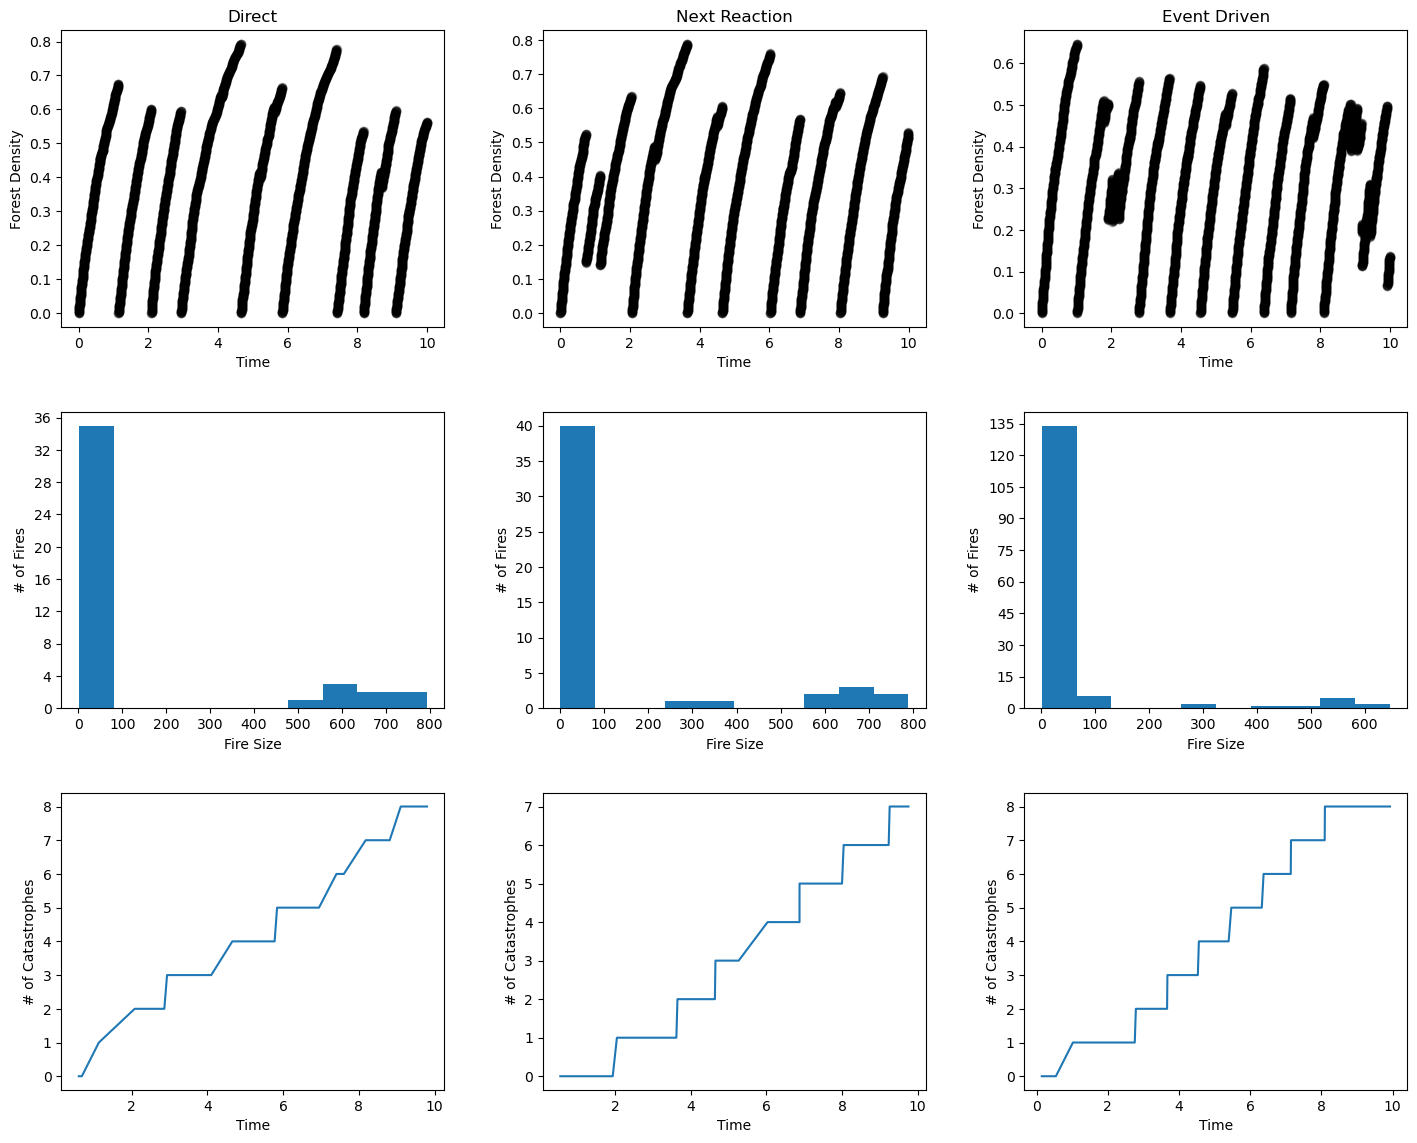

In [58]:
times, density, fire_sizes, fire_times, catastrophes, runtime = run_direct_simulation(
    1000, 10, growth_rate, lightning_rate
)
nr_times, nr_density, nr_fire_sizes, nr_fire_times, nr_catastrophes, nr_runtime = run_next_reaction_simulation(
    1000, 10, growth_rate, lightning_rate
)
ed_times, ed_density, ed_fire_sizes, ed_fire_times, ed_catastrophes, ed_runtime = run_event_driven_simulation(
    1000, 10, growth_rate, lightning_rate
)

print(f"Direct: {runtime:.2f}s | Next Reaction: {nr_runtime:.2f}s | Event Driven: {ed_runtime:.2f}s")

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.tight_layout(pad=4.0)

sims = [
    ("Direct", times, density, fire_sizes, fire_times, catastrophes),
    ("Next Reaction", nr_times, nr_density, nr_fire_sizes, nr_fire_times, nr_catastrophes),
    ("Event Driven", ed_times, ed_density, ed_fire_sizes, ed_fire_times, ed_catastrophes),
]

for col, (label, t, dens, fsizes, ftimes, cats) in enumerate(sims):
    axes[0][col].plot(t, dens, marker="o", ls='', color='black', alpha=0.25)
    axes[0][col].set_title(label)
    axes[0][col].set_xlabel('Time')
    axes[0][col].set_ylabel('Forest Density')

    axes[1][col].hist(fsizes)
    axes[1][col].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    axes[1][col].set_xlabel('Fire Size')
    axes[1][col].set_ylabel('# of Fires')

    axes[2][col].plot(ftimes, np.cumsum(cats))
    axes[2][col].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    axes[2][col].set_xlabel('Time')
    axes[2][col].set_ylabel('# of Catastrophes')

plt.show()

Direct L=10: 0.00s
Direct L=100: 0.08s
Direct L=1000: 12.20s
Direct L=10000: 1328.13s
Next Reaction L=10: 0.00s
Next Reaction L=100: 0.03s
Next Reaction L=1000: 0.45s
Next Reaction L=10000: 7.56s
Next Reaction L=100000: 287.91s
Event Driven L=10: 0.00s
Event Driven L=100: 0.01s
Event Driven L=1000: 0.13s
Event Driven L=10000: 2.16s
Event Driven L=100000: 86.42s


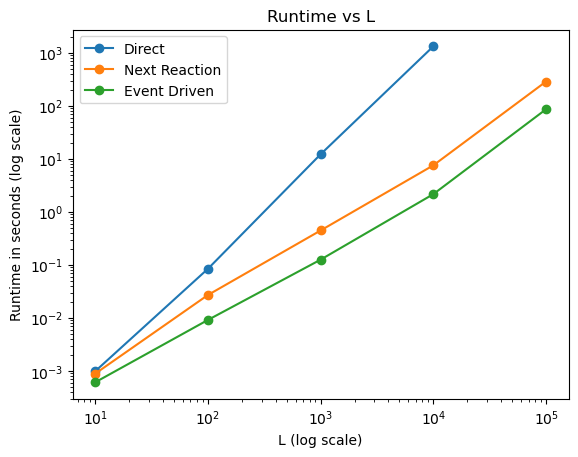

In [53]:

L_values_direct = [10, 10**2, 10**3, 10**4]
L_values_fast = [10, 10**2, 10**3, 10**4, 10**5]
T = 10

direct_runtimes = []
nr_runtimes = []
ed_runtimes = []

for L in L_values_direct:
    _, _, _, _, _, rt = run_direct_simulation(L, T, growth_rate, lightning_rate)
    direct_runtimes.append(rt)
    print(f"Direct L={L}: {rt:.2f}s")

for L in L_values_fast:
    _, _, _, _, _, rt = run_next_reaction_simulation(L, T, growth_rate, lightning_rate)
    nr_runtimes.append(rt)
    print(f"Next Reaction L={L}: {rt:.2f}s")

for L in L_values_fast:
    _, _, _, _, _, rt = run_event_driven_simulation(L, T, growth_rate, lightning_rate)
    ed_runtimes.append(rt)
    print(f"Event Driven L={L}: {rt:.2f}s")

plt.plot(L_values_direct, direct_runtimes, marker='o', label='Direct')
plt.plot(L_values_fast, nr_runtimes, marker='o', label='Next Reaction')
plt.plot(L_values_fast, ed_runtimes, marker='o', label='Event Driven')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('L (log scale)')
plt.ylabel('Runtime in seconds (log scale)')
plt.title('Runtime vs L')
plt.legend()
plt.show()